# Análisis de Sincronización: Hilbert + Kuramoto + Joint Recurrence Plots (Belousov-Zhabotinsky Delayed)

Objetivo: Identificar el desfase temporal óptimo entre una serie temporal de Belousov-Zhabotinsky y su versión retrasada
usando:
1. Transformada de Hilbert + Parámetro de orden de Kuramoto (sincronización de fase)
2. Joint Recurrence Plots (sincronización de estados en espacio de fase)

---
**Criterio de desfase óptimo (Kuramoto):** Longest Continuous Sync Segment (`max_sustained_sec`)

El score de Kuramoto se calcula como la normalización del segmento continuo más largo
donde el parámetro de orden r > 0.7 (sincronización de fase fuerte).

**Criterio de desfase óptimo (JRP):** Determinism (DET), Laminarity (LAM), Recurrence Rate (RR)

**Score combinado:** Media aritmética de ambos scores normalizados

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert
from scipy.ndimage import uniform_filter1d
from scipy.spatial.distance import pdist, squareform

from synch_analysis import BelousovZhabotinskyDataSource, SynchronizationPipeline

# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Generate delayed BZ time series using Oregonator model
# True delay: 100 steps at dt=0.01, sampling_rate=100 -> 1 second delay
# Delay is less than oscillation period (~1.3s) for JRP analysis
# Oregonator reduced model: f=1.0, q=0.05, eps=0.02 (oscillatory regime)
bz_delayed = BelousovZhabotinskyDataSource(
    f=1.0,           # Stoichiometric parameter (oscillation regime)
    q=0.05,          # Small parameter (controls oscillation amplitude)
    eps=0.02,        # Time-scale separation
    dt=0.01,
    initial_values=[0.1, 0.1],
    iterations=3000,
    variable='x',
    delay_steps=30,  # True delay to recover (1 second at 100 Hz)
    noise_std=0.005,   # Add noise to BOTH signals
    sampling_rate=100.0,
    transient=1500,   # Discard first 1500 samples (transient)
)

pipeline = SynchronizationPipeline(bz_delayed).run()

Loading data: Belousov-Zhabotinsky (Oregonator): f=1.0, q=0.05, eps=0.02, var=x, delay=30 steps, noise=0.005
  Signal A: BZ x (source) (1500 samples)
  Signal B: BZ x (delayed by 30 steps) (1500 samples)
Computing Hilbert transforms...
Computing Kuramoto order parameter...
  Mean R: 0.7473
  Sync ratio (R>0.8): 34.40%


In [3]:
# Extract signals from pipeline
signal_pair = pipeline.signal_pair
s1 = signal_pair.signal_b  # Source (reference)
s2 = signal_pair.signal_a  # Delayed version

# Normalize to [-1, 1] centered at 0
def normalize_zero_centered(x):
    x = np.asarray(x, dtype=float)
    x_centered = x - np.mean(x)
    max_abs = np.max(np.abs(x_centered))
    if max_abs > 0:
        return x_centered / max_abs
    return x_centered

s1_norm = normalize_zero_centered(s1)
s2_norm = normalize_zero_centered(s2)

time_axis = np.arange(len(s1_norm)) / signal_pair.sampling_rate

print(f'Signal length: {len(s1_norm)} samples')
print(f'Time duration: {time_axis[-1]:.1f} seconds')
print(f'Sampling rate: {signal_pair.sampling_rate} Hz')

Signal length: 1500 samples
Time duration: 15.0 seconds
Sampling rate: 100.0 Hz


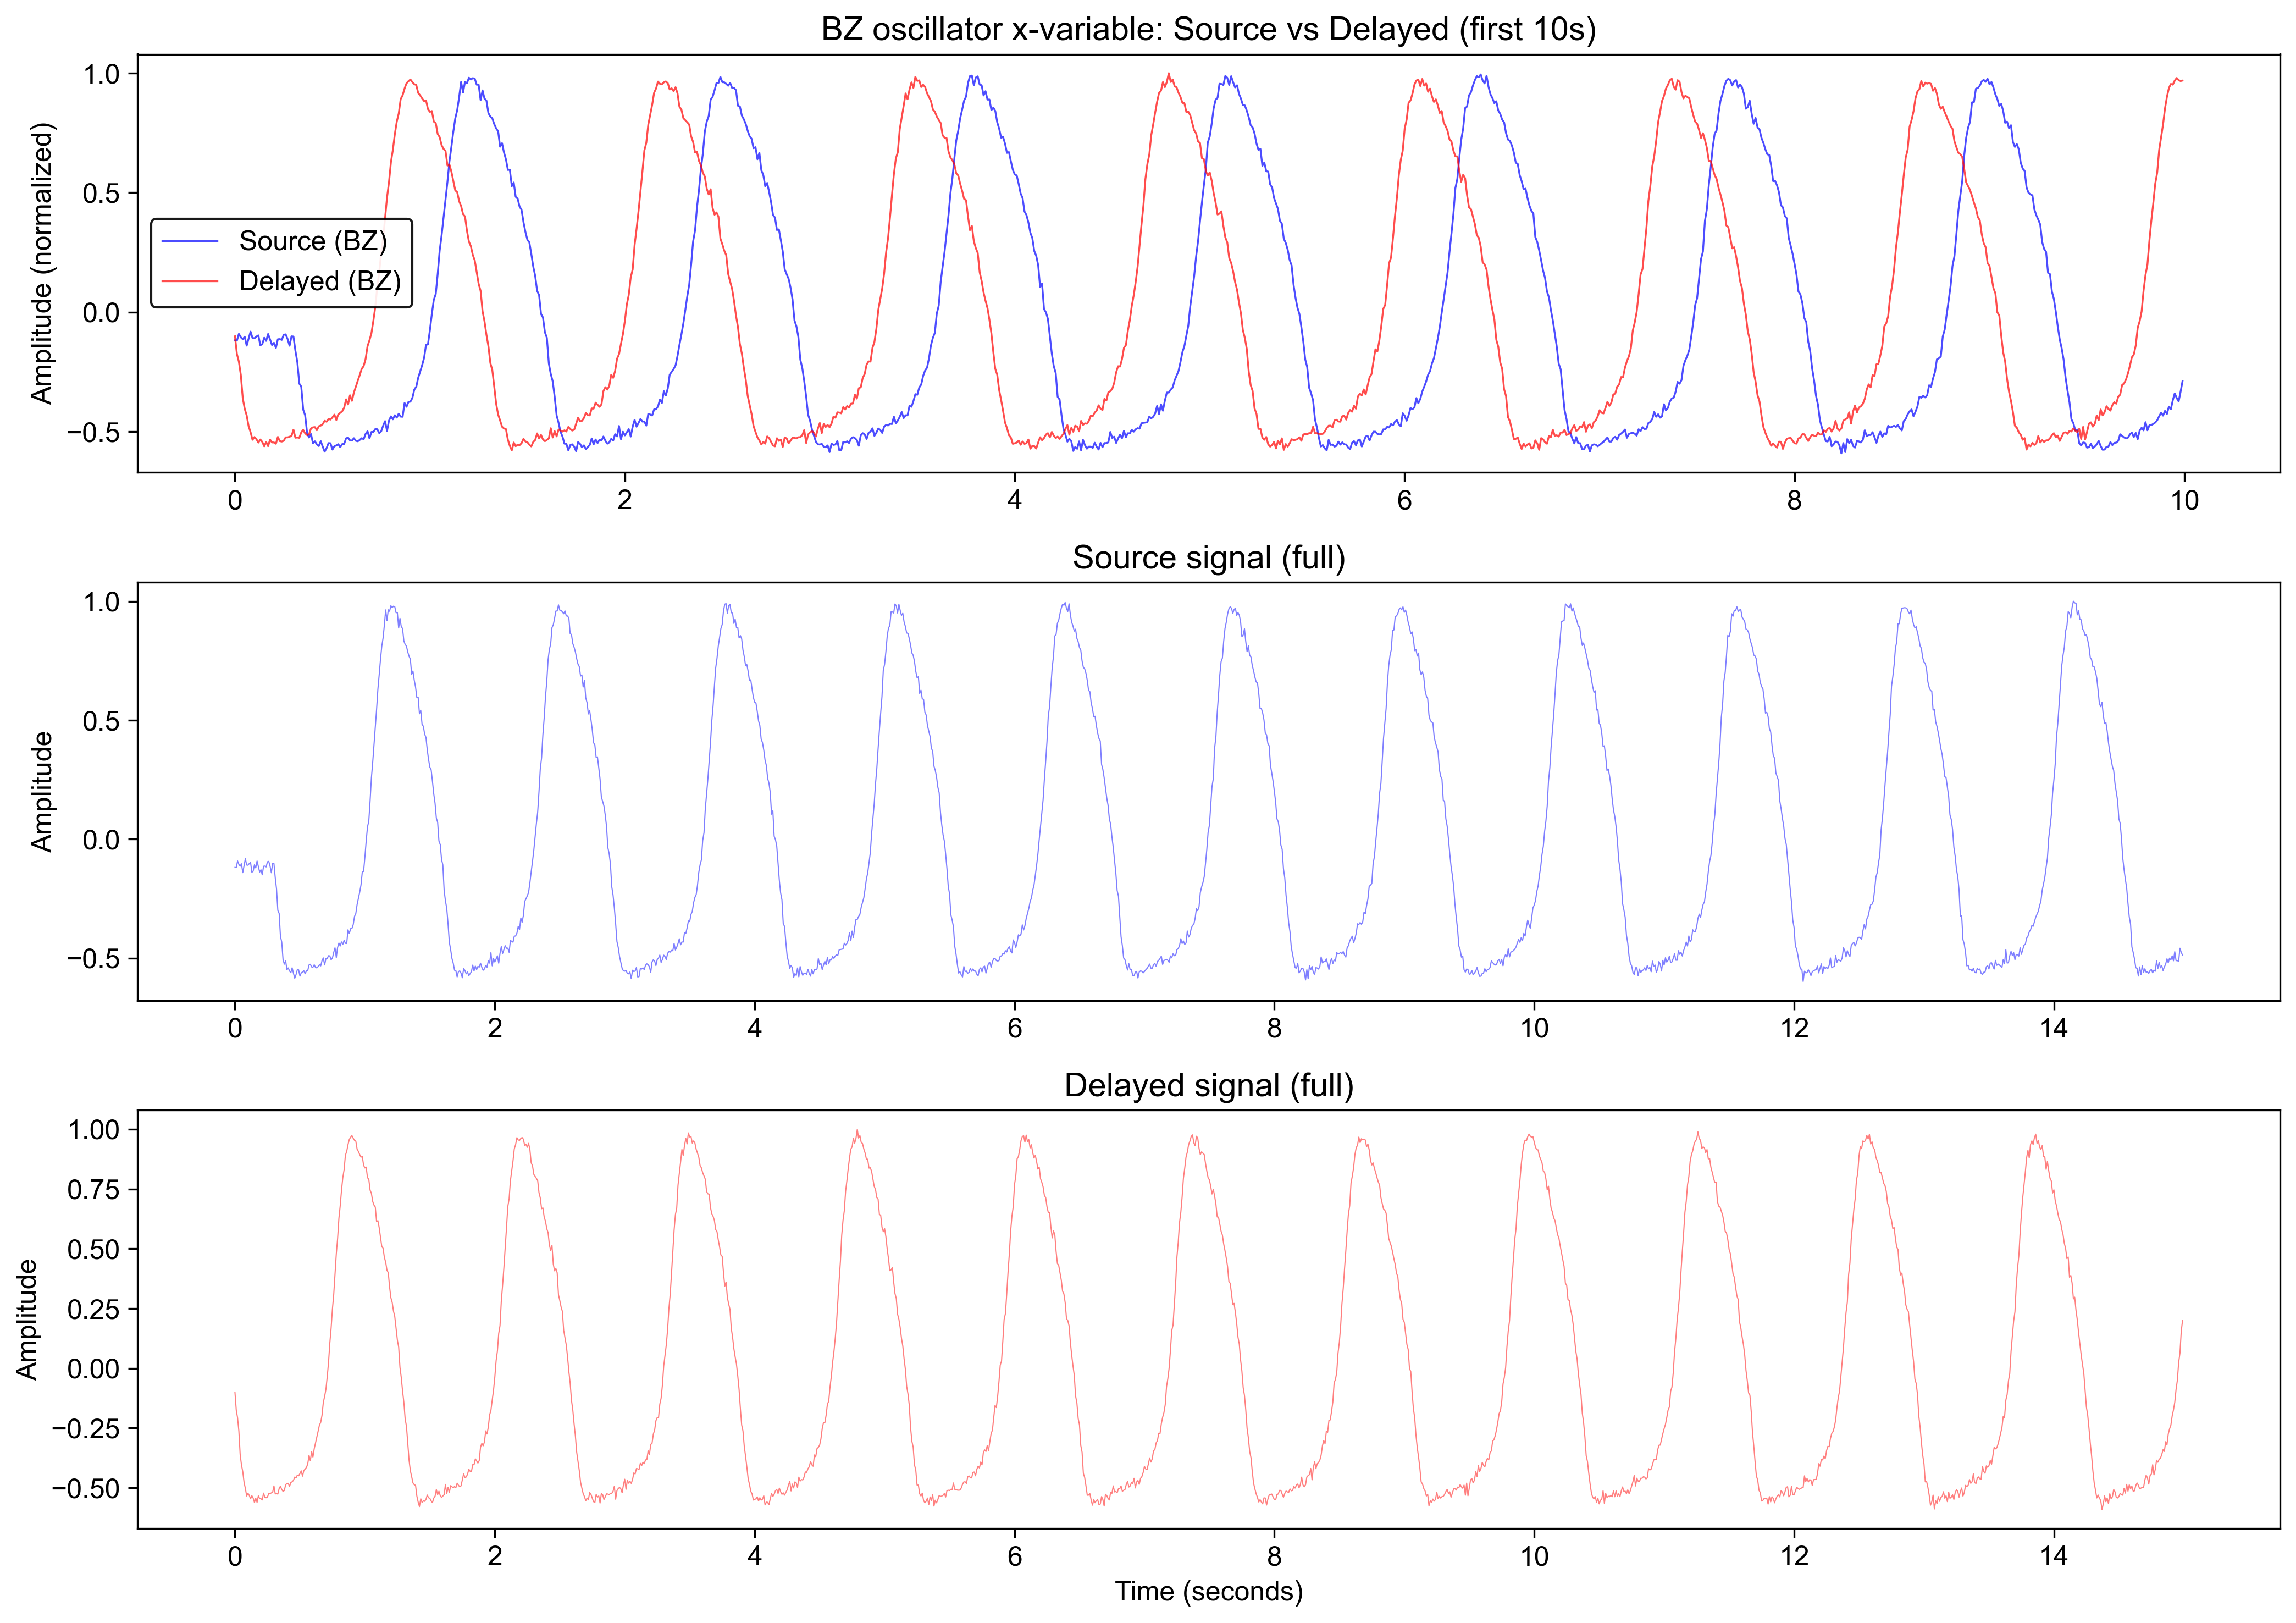

In [4]:
# Plot raw signals
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.patch.set_facecolor('white')

n_show = min(1000, len(s1_norm))
axes[0].plot(time_axis[:n_show], s1_norm[:n_show], 'b-', label='Source (BZ)', alpha=0.7, linewidth=0.8)
axes[0].plot(time_axis[:n_show], s2_norm[:n_show], 'r-', label='Delayed (BZ)', alpha=0.7, linewidth=0.8)
axes[0].set_ylabel('Amplitude (normalized)')
axes[0].set_title(f'BZ oscillator x-variable: Source vs Delayed (first {n_show/100:.0f}s)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor="black")
axes[0].grid(False)

axes[1].plot(time_axis, s1_norm, 'b-', alpha=0.5, linewidth=0.5)
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Source signal (full)')
axes[1].grid(False)

axes[2].plot(time_axis, s2_norm, 'r-', alpha=0.5, linewidth=0.5)
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title('Delayed signal (full)')
axes[2].grid(False)

plt.tight_layout()
plt.show()

In [5]:
# --- HILBERT + KURAMOTO FUNCTIONS ---
def get_phase(signal):
    analytic = hilbert(signal)
    return np.angle(analytic)

def kuramoto_order_param(phi1, phi2):
    z = 0.5 * (np.exp(1j * phi1) + np.exp(1j * phi2))
    return np.abs(z)

# --- JOINT RECURRENCE PLOT FUNCTIONS ---
def embed_time_series(x, m=3, tau=1):
    """Time-delay embedding."""
    n = len(x)
    if n < (m - 1) * tau + 1:
        return np.array([])
    embedded = np.zeros((n - (m - 1) * tau, m))
    for i in range(m):
        embedded[:, i] = x[i * tau:n - (m - 1 - i) * tau]
    return embedded

def recurrence_plot(x, threshold=None, rate=0.05):
    """Compute recurrence plot for a single time series."""
    n = len(x)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    dists = squareform(pdist(x, metric='euclidean'))
    
    if threshold is None:
        # Fixed recurrence rate threshold
        flat_dists = dists[np.triu_indices(n, k=1)]
        threshold = np.percentile(flat_dists, rate * 100)
    
    rp = dists <= threshold
    return rp, threshold

def joint_recurrence_plot(rp1, rp2):
    """Compute Joint Recurrence Plot: JRP = RP1 AND RP2."""
    return rp1 & rp2

def jrp_rqa_metrics(jrp):
    """Compute RQA metrics from Joint Recurrence Plot."""
    n = jrp.shape[0]
    
    # Recurrence Rate (RR)
    rr = np.sum(jrp) / (n * n)
    
    # Determinism (DET) - fraction of recurrence points forming diagonal lines
    diag_lengths = []
    for offset in range(-n + 1, n):
        diag = np.diag(jrp, k=offset)
        if len(diag) < 2:
            continue
        in_line = False
        length = 0
        for val in diag:
            if val:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    diag_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            diag_lengths.append(length)
    
    if len(diag_lengths) > 0:
        det = np.sum(diag_lengths) / np.sum(jrp)
        max_diag = np.max(diag_lengths)
        mean_diag = np.mean(diag_lengths)
    else:
        det = 0
        max_diag = 0
        mean_diag = 0
    
    # Laminarity (LAM) - vertical lines
    vert_lengths = []
    for col in range(n):
        in_line = False
        length = 0
        for row in range(n):
            if jrp[row, col]:
                if not in_line:
                    in_line = True
                    length = 1
                else:
                    length += 1
            else:
                if in_line and length >= 2:
                    vert_lengths.append(length)
                in_line = False
                length = 0
        if in_line and length >= 2:
            vert_lengths.append(length)
    
    if len(vert_lengths) > 0:
        lam = np.sum(vert_lengths) / np.sum(jrp)
        max_vert = np.max(vert_lengths)
    else:
        lam = 0
        max_vert = 0
    
    return {
        'RR': rr,
        'DET': det,
        'LAM': lam,
        'max_diag': max_diag,
        'mean_diag': mean_diag,
        'max_vert': max_vert
    }

Embedded shapes: s1=(1498, 3), s2=(1498, 3)
Thresholds: th1=0.0810, th2=0.0776
JRP Metrics (lag=0): RR=0.0294, DET=0.9745, LAM=0.9346
  max_diag=1498, mean_diag=12.2, max_vert=24


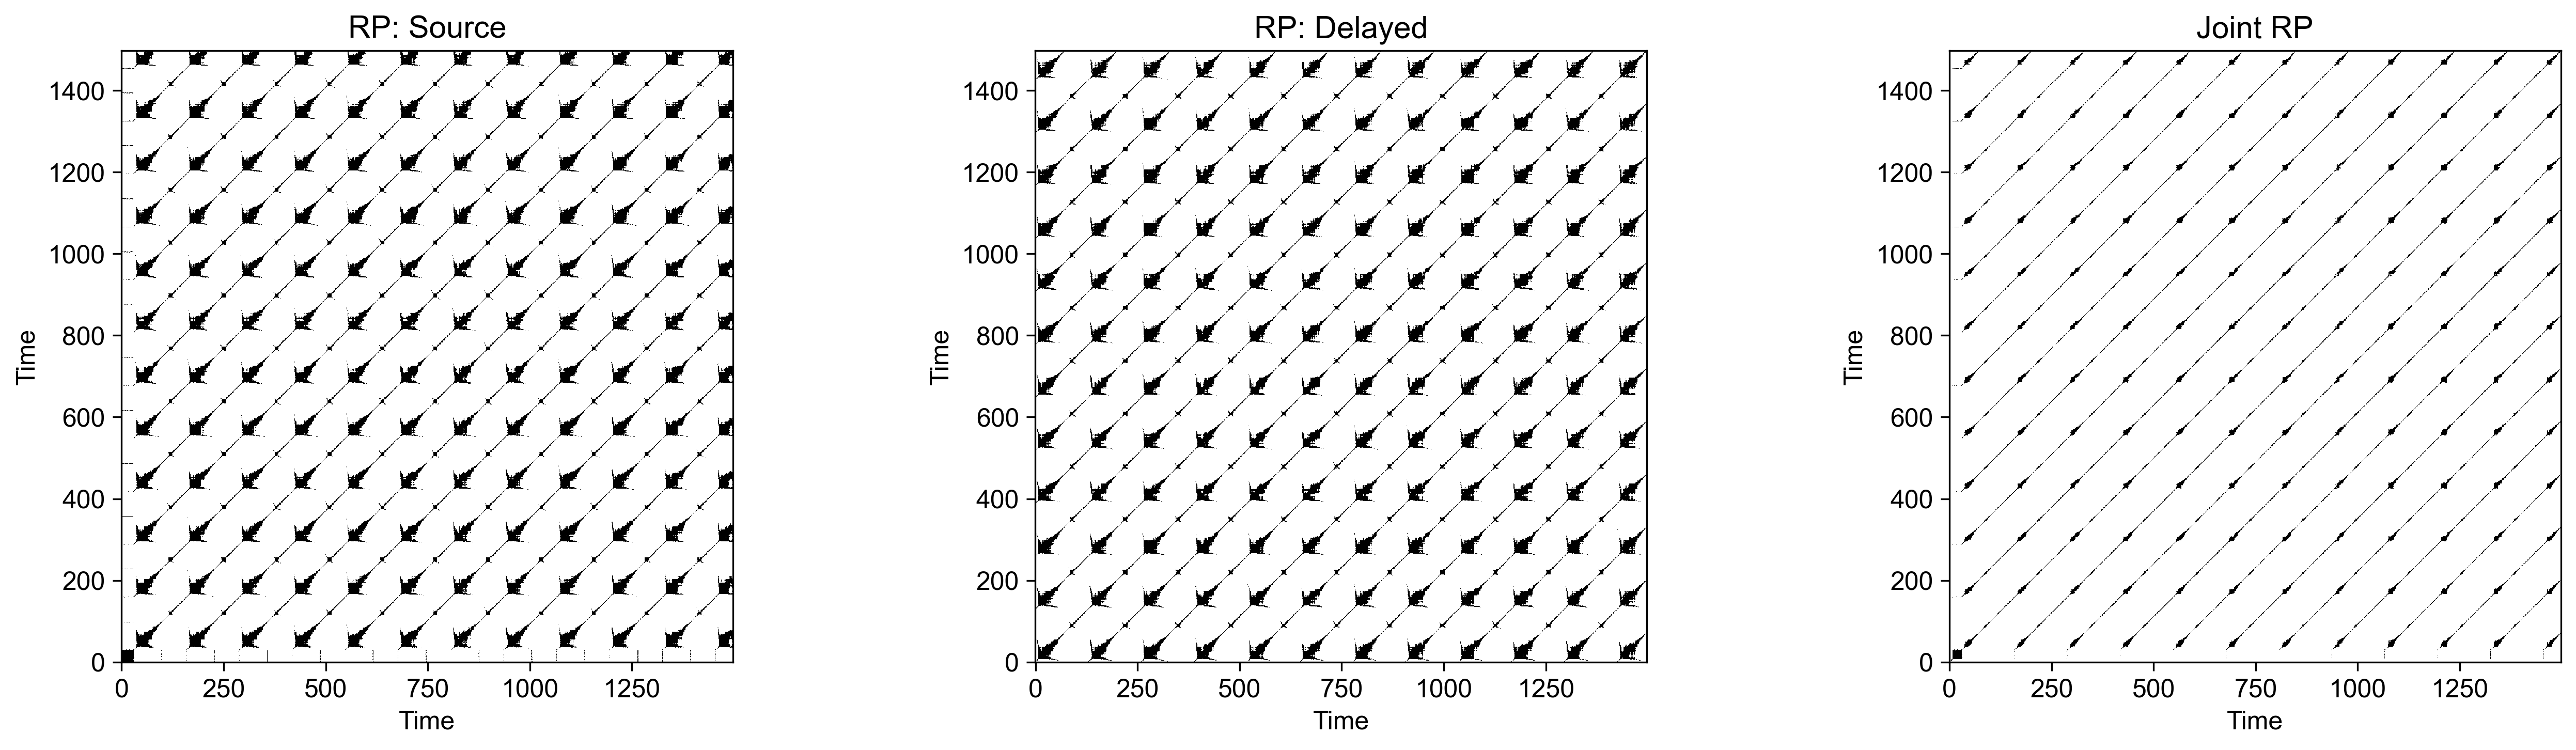

In [6]:
# Test JRP at lag=0
m, tau = 3, 1
s1_emb = embed_time_series(s1_norm, m=m, tau=tau)
s2_emb = embed_time_series(s2_norm, m=m, tau=tau)

print(f'Embedded shapes: s1={s1_emb.shape}, s2={s2_emb.shape}')

rp1, thresh1 = recurrence_plot(s1_emb, rate=0.1)
rp2, thresh2 = recurrence_plot(s2_emb, rate=0.1)
jrp = joint_recurrence_plot(rp1, rp2)

metrics = jrp_rqa_metrics(jrp)
print(f'Thresholds: th1={thresh1:.4f}, th2={thresh2:.4f}')
print(f'JRP Metrics (lag=0): RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')
print(f'  max_diag={metrics["max_diag"]}, mean_diag={metrics["mean_diag"]:.1f}, max_vert={metrics["max_vert"]}')

# Plot RPs and JRP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')
for ax, rp, title in zip(axes, [rp1, rp2, jrp], ['RP: Source', 'RP: Delayed', 'Joint RP']):
    ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel('Time')
plt.tight_layout()
plt.show()

In [7]:
# Sweep lags with both Kuramoto and JRP metrics
max_lag = 70  # steps (0.7 seconds)
lag_step = 1
lags = np.arange(-max_lag, max_lag + 1, lag_step)

results = []

# Pre-compute s1_emb using the smoothed signal (s1 doesn't shift)
# Smooth the signals for JRP analysis
s1_smooth = uniform_filter1d(s1_norm, size=5, mode='reflect')
s2_smooth = uniform_filter1d(s2_norm, size=5, mode='reflect')
s1_emb = embed_time_series(s1_smooth, m=m, tau=tau)

for lag in lags:
    # Shift s2
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    # --- KURAMOTO ---
    phi1 = get_phase(s1_norm)
    phi2 = get_phase(s2_shifted)
    r = kuramoto_order_param(phi1, phi2)
    
    r_mean = np.mean(r)
    r_std = np.std(r)
    threshold = 0.7
    frac_above = np.mean(r > threshold)
    above = r > threshold
    max_sustained = 0
    current = 0
    for val in above:
        if val:
            current += 1
            max_sustained = max(max_sustained, current)
        else:
            current = 0
    
    # --- JRP (only compute at coarser resolution for speed) ---
    jrp_metrics = {'RR': 0, 'DET': 0, 'LAM': 0, 'max_diag': 0}
    if lag % 5 == 0:  # Compute JRP every 5 steps
        try:
            # Shift s2_smooth by the lag (same as done for s2_norm)
            if lag > 0:
                s2_smooth_shifted = np.concatenate([np.full(lag, np.nan), s2_smooth[:-lag]])
            elif lag < 0:
                s2_smooth_shifted = np.concatenate([s2_smooth[-lag:], np.full(-lag, np.nan)])
            else:
                s2_smooth_shifted = s2_smooth.copy()
            s2_smooth_shifted = pd.Series(s2_smooth_shifted).interpolate(limit_direction='both').values
            
            # Use smoothed signal for embedding
            s2_emb = embed_time_series(s2_smooth_shifted, m=m, tau=tau)
            min_len = min(len(s1_emb), len(s2_emb))
            if min_len > 100:
                rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.1)
                rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.1)
                jrp = joint_recurrence_plot(rp1, rp2)
                jrp_metrics = jrp_rqa_metrics(jrp)
        except:
            pass
    
    results.append({
        'lag': lag,
        'lag_sec': lag / signal_pair.sampling_rate,
        'r_mean': r_mean,
        'r_std': r_std,
        'frac_above_07': frac_above,
        'max_sustained_sec': max_sustained / signal_pair.sampling_rate,
        'jrp_RR': jrp_metrics['RR'],
        'jrp_DET': jrp_metrics['DET'],
        'jrp_LAM': jrp_metrics['LAM'],
        'jrp_max_diag': jrp_metrics['max_diag']
    })
    
    if len(results) % 50 == 0:
        print(f'Processed {len(results)}/{len(lags)} lags...')

results_df = pd.DataFrame(results)

Processed 50/141 lags...
Processed 100/141 lags...


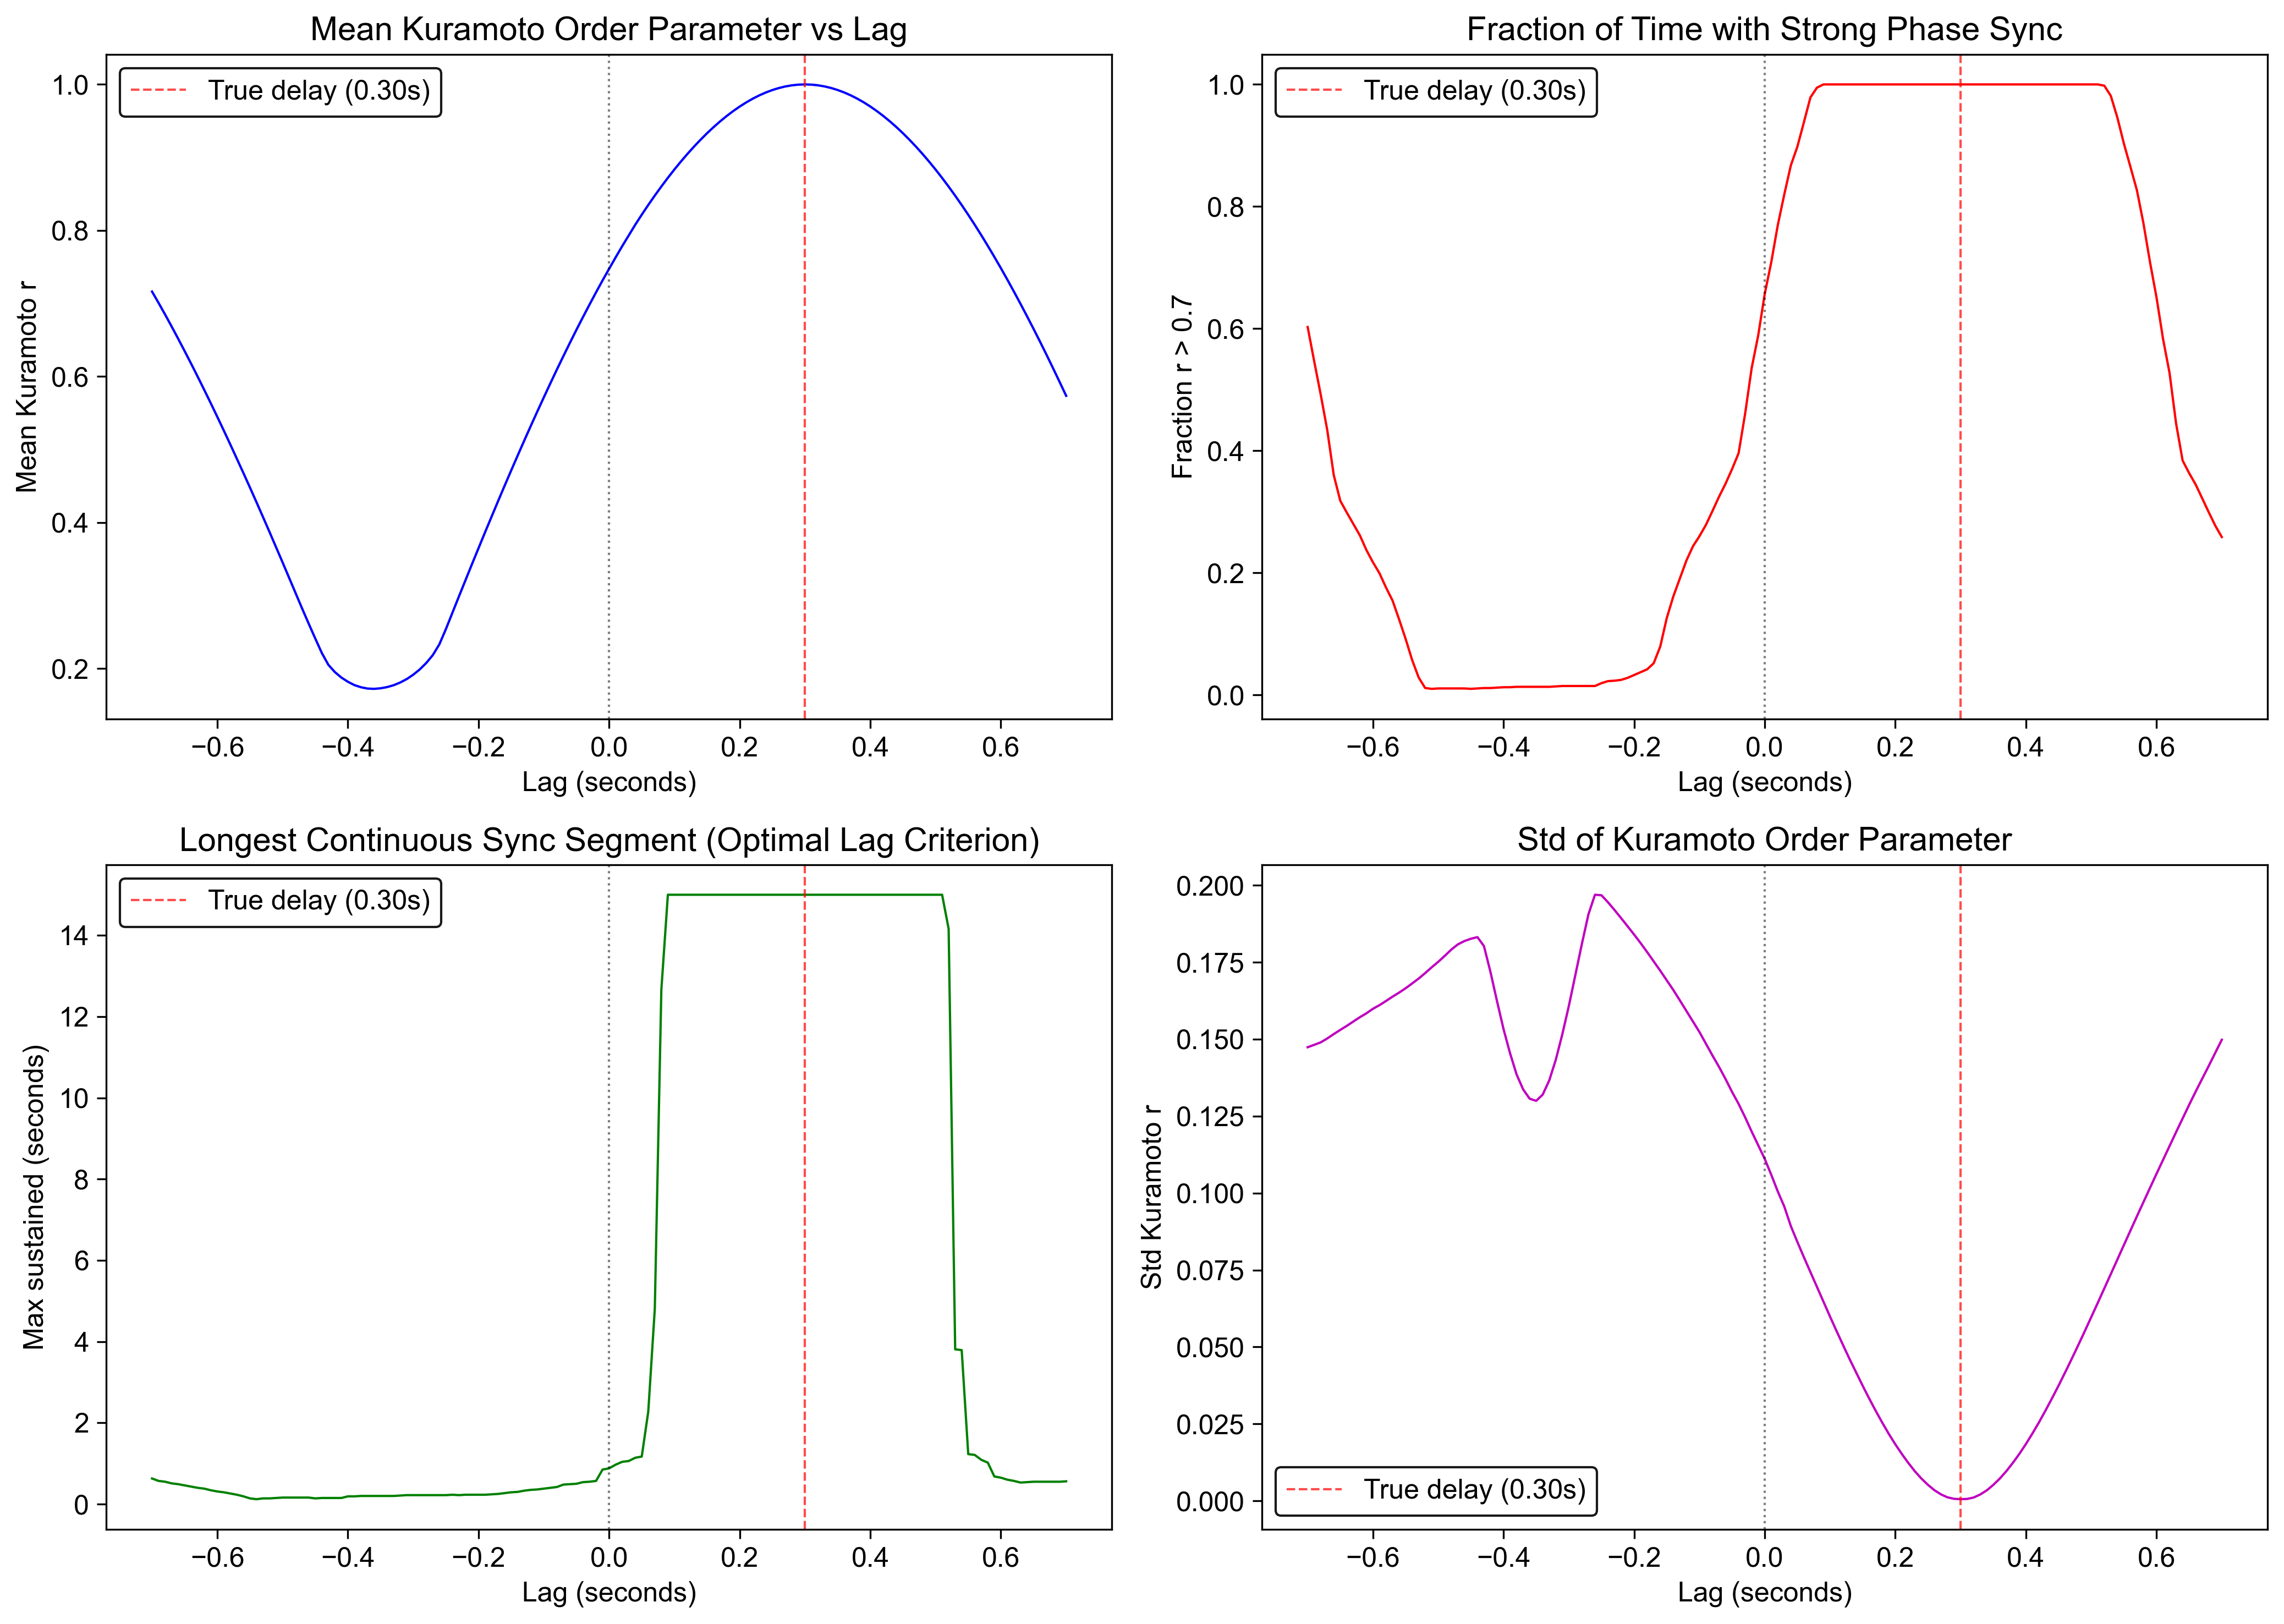

In [8]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

true_delay_sec = 30 / signal_pair.sampling_rate  # True delay in seconds

axes[0, 0].plot(results_df['lag_sec'], results_df['r_mean'], 'b-', linewidth=1)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(results_df['lag_sec'], results_df['frac_above_07'], 'r-', linewidth=1)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction r > 0.7')
axes[0, 1].set_title('Fraction of Time with Strong Phase Sync')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(results_df['lag_sec'], results_df['max_sustained_sec'], 'g-', linewidth=1)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max sustained (seconds)')
axes[1, 0].set_title('Longest Continuous Sync Segment (Optimal Lag Criterion)')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(results_df['lag_sec'], results_df['r_std'], 'm-', linewidth=1)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Std Kuramoto r')
axes[1, 1].set_title('Std of Kuramoto Order Parameter')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()

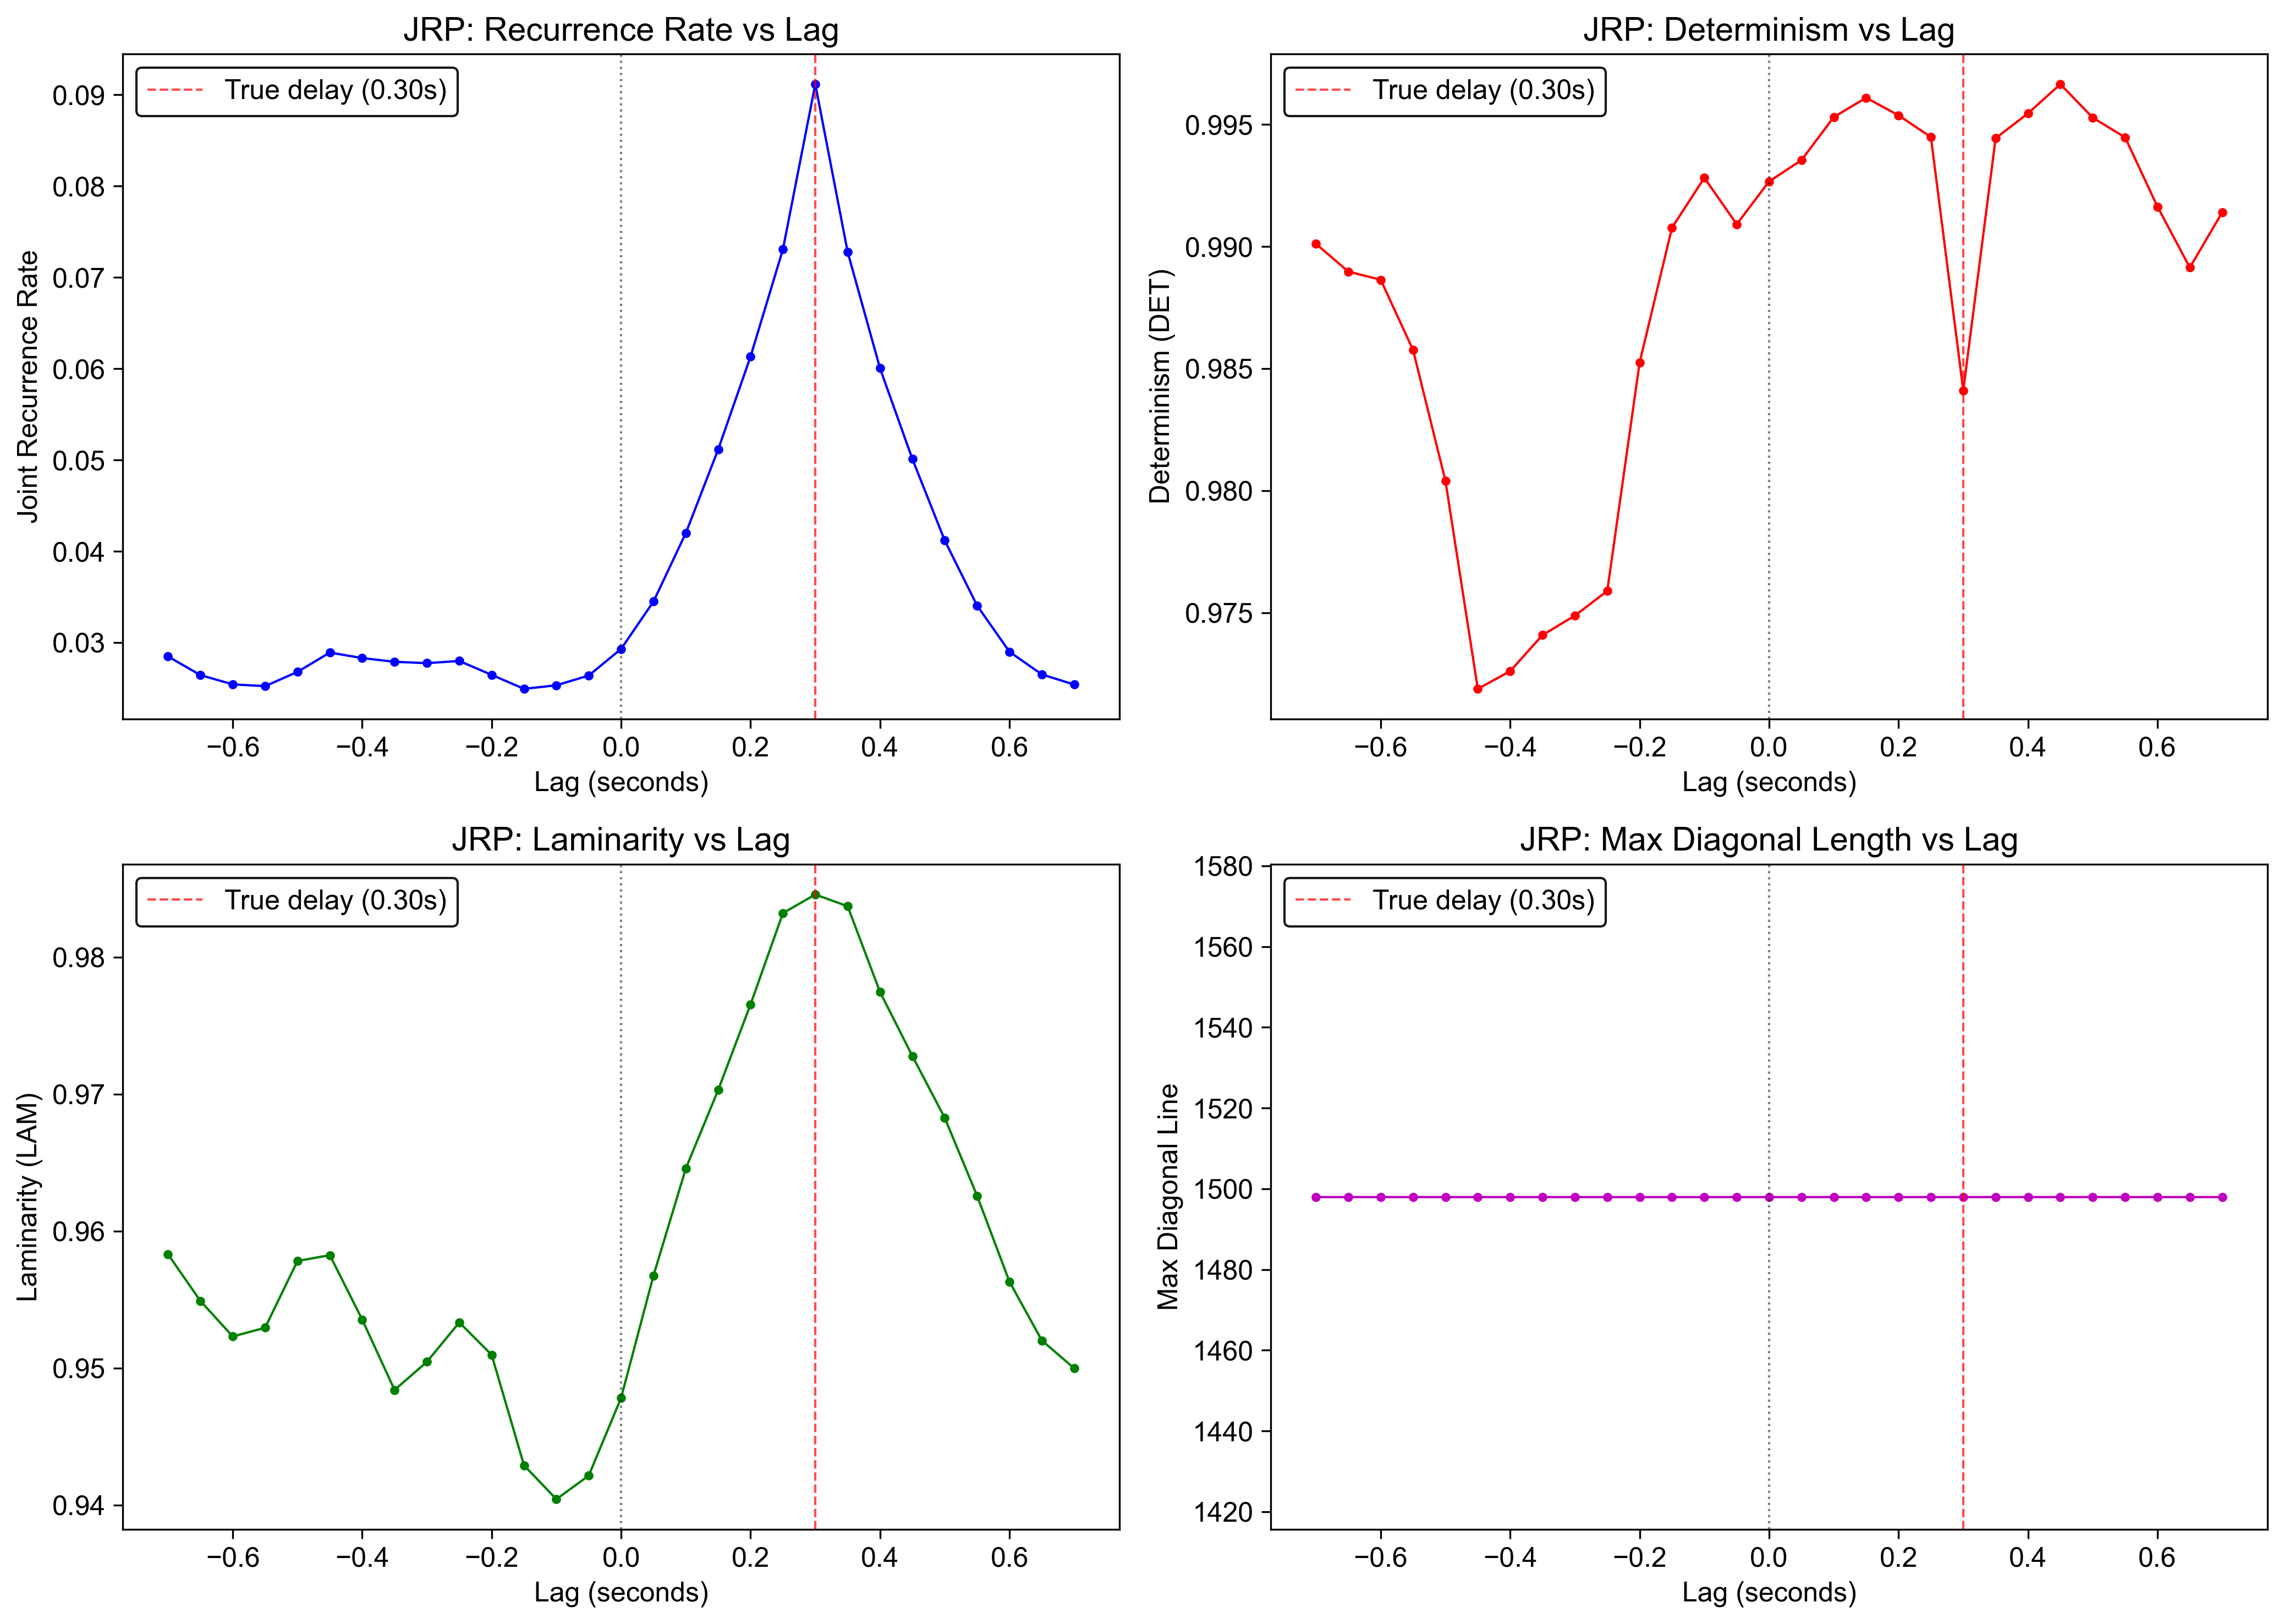

In [9]:
# Plot JRP metrics (only computed every 10 steps = 0.01s)
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

true_delay_sec = 30 / signal_pair.sampling_rate  # True delay in seconds

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[0, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism (DET)')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 0].plot(jrp_df['lag_sec'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity (LAM)')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor="black")

axes[1, 1].plot(jrp_df['lag_sec'], jrp_df['jrp_max_diag'], 'm-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Max Diagonal Line')
axes[1, 1].set_title('JRP: Max Diagonal Length vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.2f}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor="black")

plt.tight_layout()

In [10]:
# Combined analysis: Find optimal lag from both methods
# KURAMOTO: Use 'Fraction of time with strong phase sync' (frac_above_07) AND 'Max Mean r' (r_mean) as criteria
# JRP: Use Determinism (DET), Laminarity (LAM), Recurrence Rate (RR) as primary criteria
# Discard extreme lags (±max_lag) from JRP analysis
def normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v > min_v:
        return (series - min_v) / (max_v - min_v)
    return series * 0

# Kuramoto score = frac_above_07 * r_mean (combining two criteria)
results_df['kuramoto_score'] = normalize(results_df['frac_above_07']) * normalize(results_df['r_mean'])

# JRP score = normalized product of DET, LAM, RR (excluding extreme lags)
jrp_valid = results_df[(results_df['lag'] != -max_lag) & (results_df['lag'] != max_lag) & (results_df['jrp_RR'] > 0)].copy()
results_df['jrp_score'] = 0.0
if len(jrp_valid) > 0:
    jrp_score_vals = (
        normalize(jrp_valid['jrp_DET']) * normalize(jrp_valid['jrp_LAM']) * normalize(jrp_valid['jrp_RR'])
    )
    results_df.loc[jrp_valid.index, 'jrp_score'] = jrp_score_vals
    jrp_valid['jrp_score'] = jrp_score_vals  # Also add to jrp_valid for nlargest
results_df['combined_score'] = (results_df['kuramoto_score'] + results_df['jrp_score']) / 2

print('=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'kuramoto_score']].to_string(index=False))

print('\n=== Top 10 by JRP Score (DET × LAM × RR, excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[['lag_sec', 'jrp_RR', 'jrp_DET', 'jrp_LAM', 'jrp_max_diag', 'jrp_score']].to_string(index=False))

print('\n=== Top 10 by Combined Score ===')
print(results_df.nlargest(10, 'combined_score')[['lag_sec', 'r_mean', 'frac_above_07', 'max_sustained_sec', 'jrp_RR', 'jrp_DET', 'combined_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (frac_above_07 × r_mean) ===
 lag_sec   r_mean  frac_above_07  max_sustained_sec  kuramoto_score
    0.30 0.999852            1.0               15.0        1.000000
    0.31 0.999552            1.0               15.0        0.999638
    0.29 0.999537            1.0               15.0        0.999620
    0.32 0.998626            1.0               15.0        0.998519
    0.28 0.998600            1.0               15.0        0.998488
    0.33 0.997088            1.0               15.0        0.996661
    0.27 0.997058            1.0               15.0        0.996625
    0.34 0.994950            1.0               15.0        0.994077
    0.26 0.994902            1.0               15.0        0.994020
    0.35 0.992195            1.0               15.0        0.990749

=== Top 10 by JRP Score (DET × LAM × RR, excl. extreme lags) ===
 lag_sec   jrp_RR  jrp_DET  jrp_LAM  jrp_max_diag  jrp_score
    0.35 0.072781 0.994440 0.983719          1498   0.645062
    0.

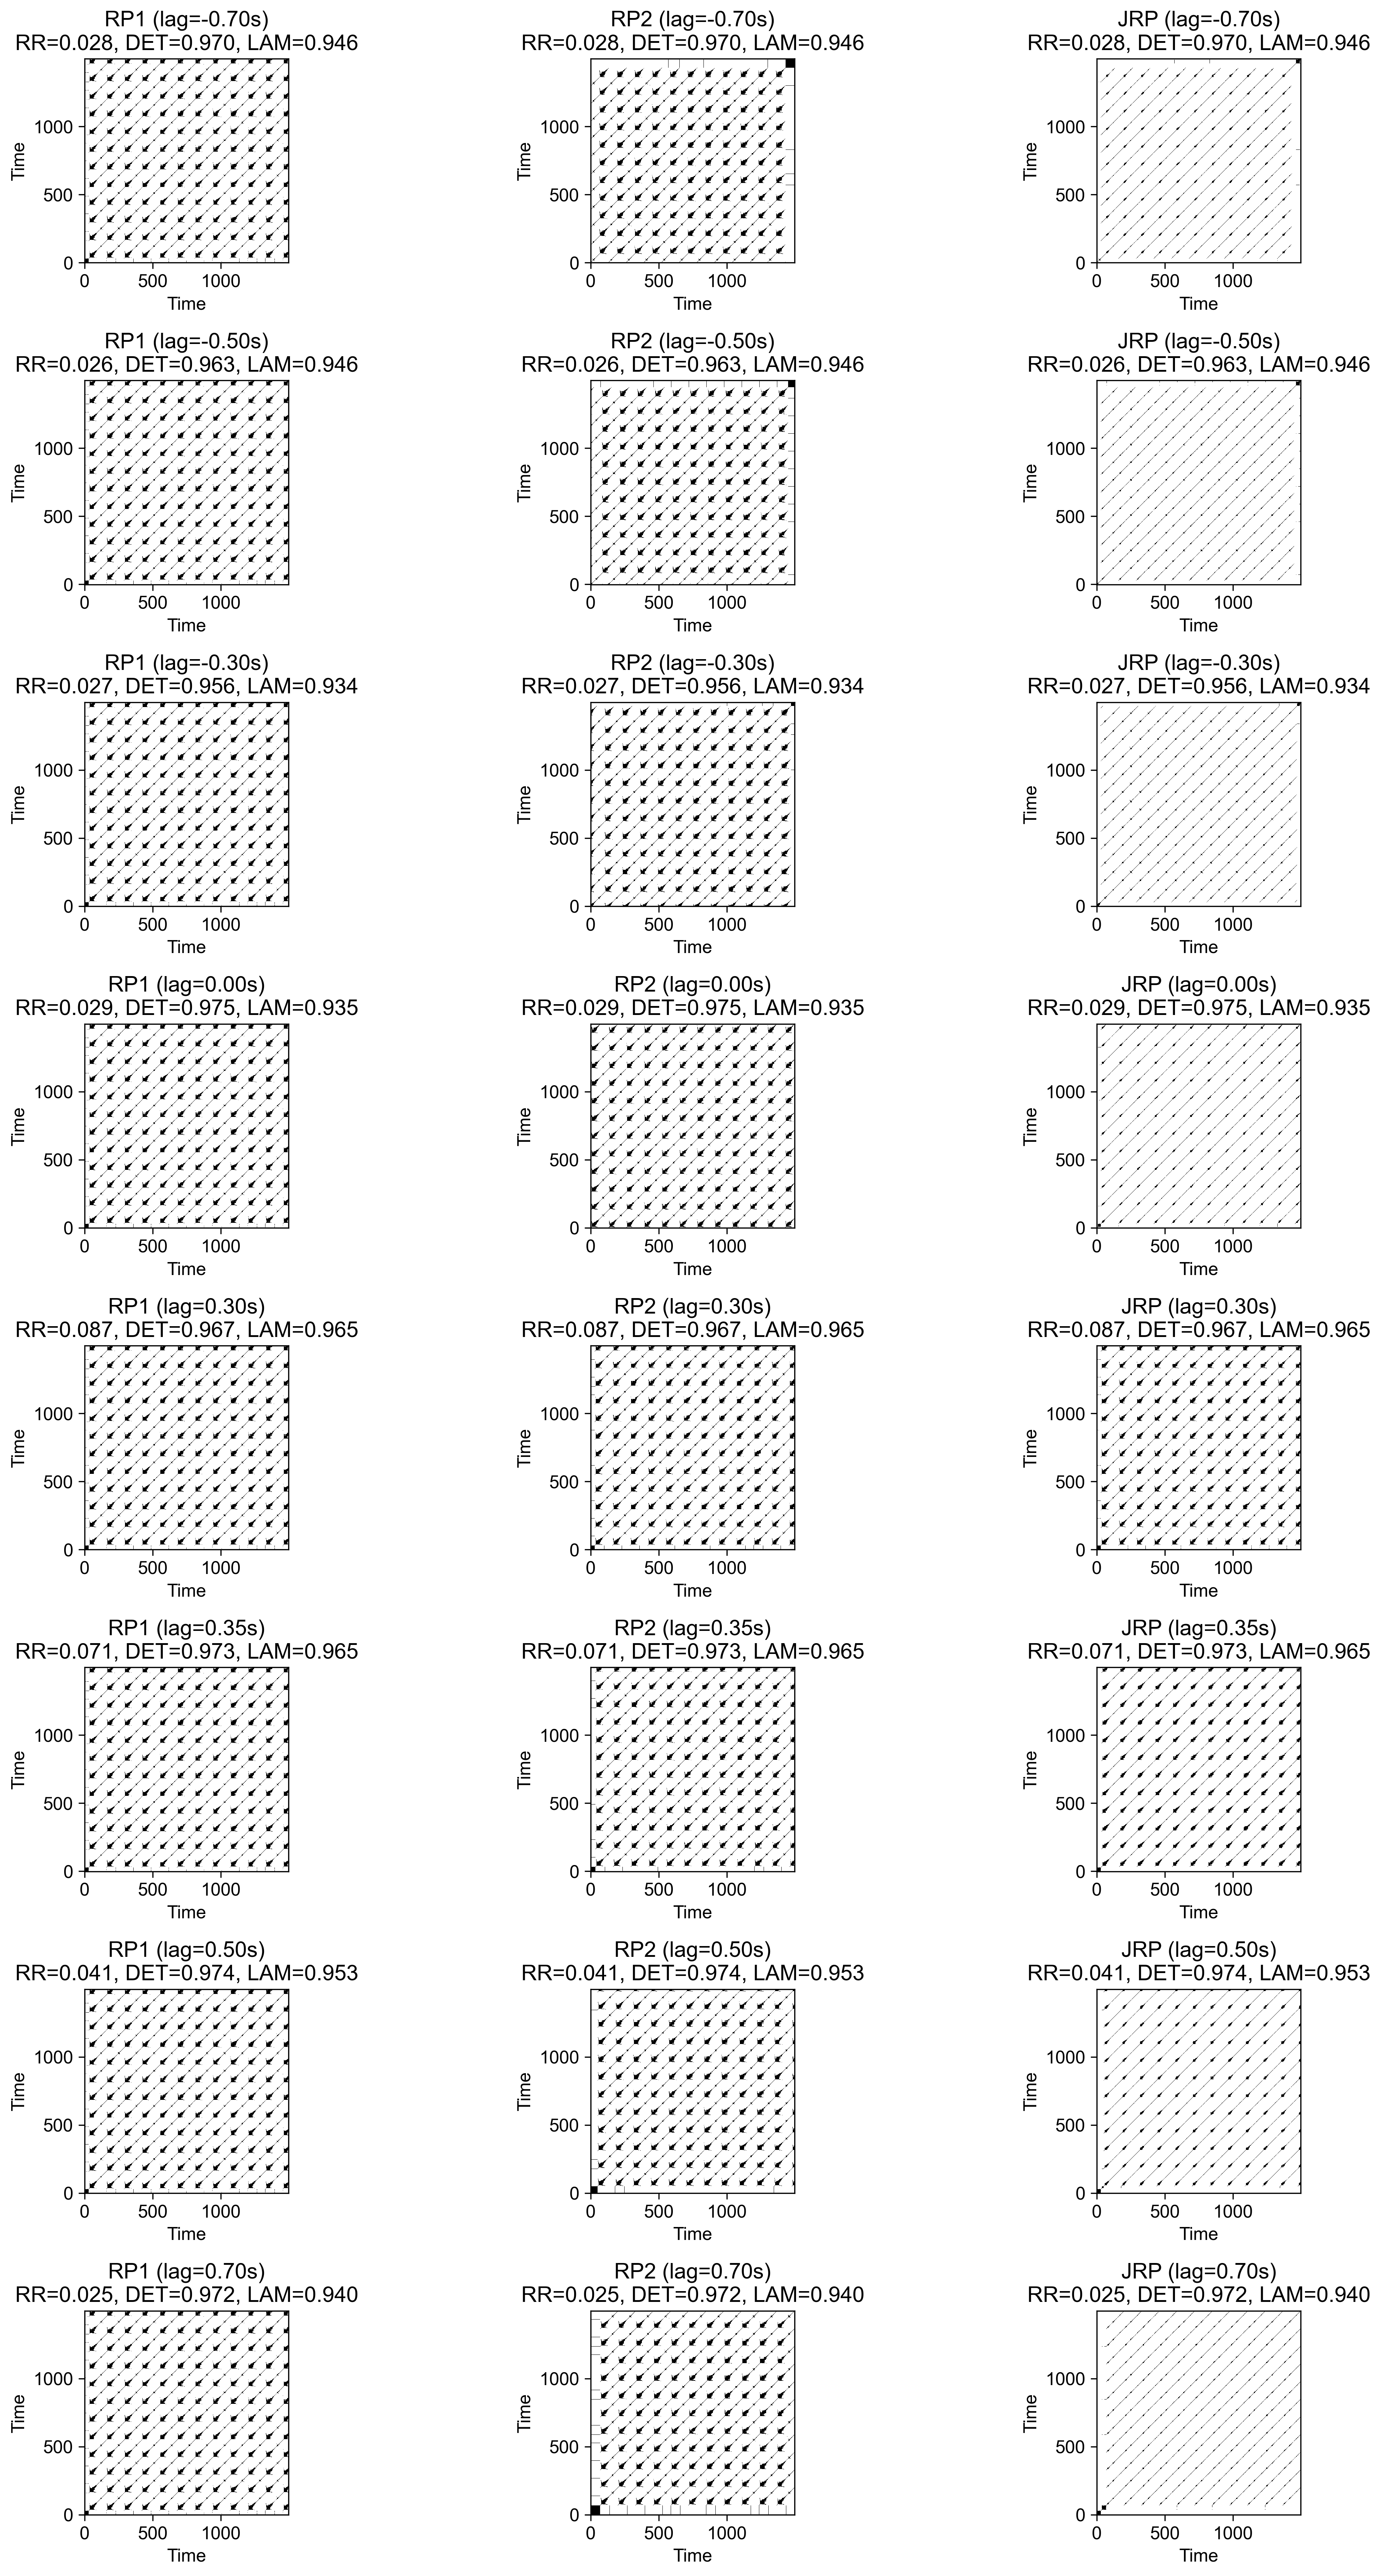

In [11]:
# Detailed JRP visualization at key lags
# Include best Kuramoto lag (frac_above_07 × r_mean) and best JRP lag
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_jrp_lag = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 0
true_delay_lag = 30

key_lags = [-max_lag, -30, -50, 0, 30, 50, 70, true_delay_lag, best_kuramoto_lag, best_jrp_lag]
key_lags = sorted(set([l for l in key_lags if -max_lag <= l <= max_lag]))

fig, axes = plt.subplots(len(key_lags), 3, figsize=(15, 3*len(key_lags)))
fig.patch.set_facecolor('white')
if len(key_lags) == 1:
    axes = axes.reshape(1, -1)

for idx, lag in enumerate(key_lags):
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_norm, m=m, tau=tau)
    s2_emb = embed_time_series(s2_shifted, m=m, tau=tau)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.1)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.1)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        for ax, rp, title in zip(axes[idx], [rp1, rp2, jrp],
                                  [f'RP1 (lag={lag/100:.2f}s)', f'RP2 (lag={lag/100:.2f}s)', f'JRP (lag={lag/100:.2f}s)']):
            im = ax.imshow(rp.T, origin='lower', cmap='binary', aspect='equal', interpolation='nearest')
            ax.set_title(f'{title}\nRR={metrics["RR"]:.3f}, DET={metrics["DET"]:.3f}, LAM={metrics["LAM"]:.3f}')
            ax.set_xlabel('Time')
            ax.set_ylabel('Time')
    else:
        for ax in axes[idx]:
            ax.text(0.5, 0.5, 'Too short', ha='center', va='center')

plt.tight_layout()

In [12]:
# JRP at best Kuramoto lag (max_sustained)
best_kuramoto_lag = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])

for lag in [best_kuramoto_lag, true_delay_lag]:
    if lag > 0:
        s2_shifted = np.concatenate([np.full(lag, np.nan), s2_norm[:-lag]])
    elif lag < 0:
        s2_shifted = np.concatenate([s2_norm[-lag:], np.full(-lag, np.nan)])
    else:
        s2_shifted = s2_norm.copy()
    s2_shifted = pd.Series(s2_shifted).interpolate(limit_direction='both').values
    
    s1_emb = embed_time_series(s1_norm, m=m, tau=tau)
    s2_emb = embed_time_series(s2_shifted, m=m, tau=tau)
    min_len = min(len(s1_emb), len(s2_emb))
    
    if min_len > 50:
        rp1, _ = recurrence_plot(s1_emb[:min_len], rate=0.1)
        rp2, _ = recurrence_plot(s2_emb[:min_len], rate=0.1)
        jrp = joint_recurrence_plot(rp1, rp2)
        metrics = jrp_rqa_metrics(jrp)
        
        print(f'\n=== Lag = {lag} steps ({lag/100:.2f}s) ===')
        print(f'  JRP: RR={metrics["RR"]:.4f}, DET={metrics["DET"]:.4f}, LAM={metrics["LAM"]:.4f}')


=== Lag = 30 steps (0.30s) ===
  JRP: RR=0.0865, DET=0.9672, LAM=0.9655

=== Lag = 30 steps (0.30s) ===
  JRP: RR=0.0865, DET=0.9672, LAM=0.9655


In [13]:
# Save results
results_df.to_parquet('../data/kuramoto_jrp_lag_sweep_bz_delayed.parquet')
print('Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_bz_delayed.parquet')

# Summary
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_sec']
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 'N/A'
best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])

true_delay = 30  # steps
sampling_rate = signal_pair.sampling_rate

print(f'\n=== FINAL SUMMARY ===')
print(f'True delay:                                         {true_delay} steps ({true_delay/sampling_rate:.2f}s)')
print(f'Best lag (Kuramoto - frac_above_07 × r_mean):     {best_kuramoto} steps ({best_kuramoto/sampling_rate:.2f}s)  [max_sustained={best_kuramoto_sustained:.2f}s, frac_above_07={best_kuramoto_frac:.3f}, r_mean={best_kuramoto_r:.3f}]')
print(f'Best lag (JRP - DET/LAM/RR, excl. extreme lags):    {best_jrp} steps ({best_jrp/sampling_rate:.2f}s)')
print(f'Best lag (Combined):                               {best_combined} steps ({best_combined/sampling_rate:.2f}s)')

error_kuramoto = abs(best_kuramoto - true_delay) / sampling_rate
error_jrp = abs(best_jrp - true_delay) / sampling_rate if best_jrp != 'N/A' else 'N/A'
error_combined = abs(best_combined - true_delay) / sampling_rate
print(f'\nErrors vs true delay:')
print(f'  Kuramoto:  {error_kuramoto:.2f}s')
print(f'  JRP (DET/LAM/RR):       {error_jrp:.2f}s' if error_jrp != 'N/A' else '  JRP (DET/LAM/RR):       N/A')

Saved lag sweep results to ../data/kuramoto_jrp_lag_sweep_bz_delayed.parquet

=== FINAL SUMMARY ===
True delay:                                         30 steps (0.30s)
Best lag (Kuramoto - frac_above_07 × r_mean):     30 steps (0.30s)  [max_sustained=15.00s, frac_above_07=1.000, r_mean=1.000]
Best lag (JRP - DET/LAM/RR, excl. extreme lags):    35 steps (0.35s)
Best lag (Combined):                               35 steps (0.35s)

Errors vs true delay:
  Kuramoto:  0.00s
  JRP (DET/LAM/RR):       0.05s
